<a href="https://colab.research.google.com/github/AarshiMukherjee/VAC_ML_Algorithm_using_FPGA/blob/main/VAC_Course_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pretrained CNN Model

In [2]:
# 1. IMPORT LIBRARIES
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


In [3]:
# 2. PATHS
train_dir = "/content/drive/MyDrive/MedNode_train"
test_dir = "/content/drive/MyDrive/MedNode_test"

IMG_SIZE = 224
BATCH_SIZE = 32


In [4]:
# 3. DATA GENERATORS
train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=20,
zoom_range=0.2,
horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
train_dir,
target_size=(IMG_SIZE, IMG_SIZE),
batch_size=BATCH_SIZE,
class_mode='categorical',
shuffle=True)
test_generator = test_datagen.flow_from_directory(
test_dir,
target_size=(IMG_SIZE, IMG_SIZE),
batch_size=BATCH_SIZE,
class_mode='categorical',
shuffle=False
)

Found 2552 images belonging to 2 classes.
Found 34 images belonging to 2 classes.


In [5]:
# 4. LOAD PRETRAINED VGG16 MODEL
base_model = VGG16(
weights='imagenet',
include_top=False,
input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
base_model.trainable = False # Freeze base layers

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
optimizer=Adam(learning_rate=1e-3),
loss='categorical_crossentropy',
metrics=['categorical_accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
# 5. TRAIN MODEL
history = model.fit(
train_generator,
epochs=10,
validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 615s 7s/step - categorical_accuracy: 0.6333 - loss: 1.4795 - val_categorical_accuracy: 0.7059 - val_loss: 0.5977
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 503ms/step - categorical_accuracy: 0.7977 - loss: 0.4266 - val_categorical_accuracy: 0.6765 - val_loss: 0.6833
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 504ms/step - categorical_accuracy: 0.8361 - loss: 0.3732 - val_categorical_accuracy: 0.6765 - val_loss: 0.8258
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 558ms/step - categorical_accuracy: 0.8358 - loss: 0.3662 - val_categorical_accuracy: 0.6765 - val_loss: 0.9153
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 530ms/step - categorical_accuracy: 0.8512 - loss: 0.3234 - val_categorical_accuracy: 0.7059 - val_loss: 0.7024
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 538ms/step - categorical_accuracy: 0.8702 - loss: 0.2807 - val_categorical_accuracy: 0.6765 - val_loss: 0.7809
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 509ms/step - categorical_accuracy: 0.8483 

In [8]:
# 6. EVALUATION
test_loss, test_acc = model.evaluate(test_generator)
print("\nTest Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - categorical_accuracy: 0.6697 - loss: 0.8740 

Test Accuracy: 0.6764705777168274


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 615ms/step

Confusion Matrix:
 [[ 4 10]
 [ 1 19]]

Classification Report:

              precision    recall  f1-score   support

      cancer       0.80      0.29      0.42        14
     healthy       0.66      0.95      0.78        20

    accuracy                           0.68        34
   macro avg       0.73      0.62      0.60        34
weighted avg       0.71      0.68      0.63        34



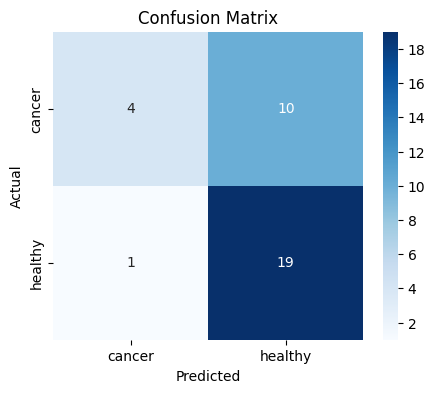

In [9]:
# 7. CONFUSION MATRIX
test_generator.reset()
pred_probs = model.predict(test_generator)
# Fix: Get predicted labels by taking the argmax of probabilities
pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_generator.classes

cm = confusion_matrix(true_labels, pred_labels)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
# Make sure target_names match the number of classes in true_labels and pred_labels
print(classification_report(true_labels, pred_labels, target_names=list(test_generator.class_indices.keys())))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
xticklabels=test_generator.class_indices.keys(),
yticklabels=test_generator.class_indices.keys(),
cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

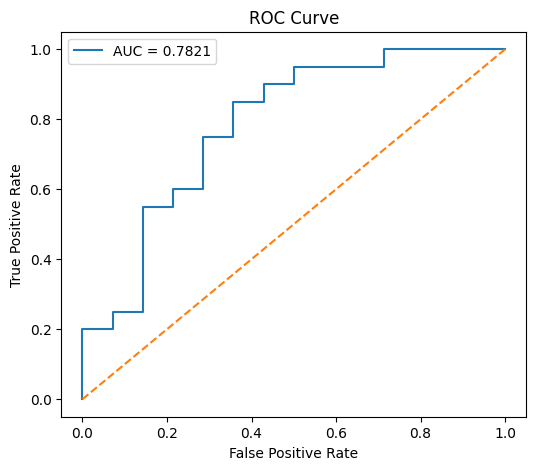

AUC Score: 0.7821428571428571


In [10]:
# 8. ROC CURVE
# Fix: For ROC curve, use probabilities of the positive class (assuming index 1 is positive)
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

#Attention Mechanism

In [12]:
#Keep epochs same for all types of models
from tensorflow.keras.layers import Conv2D, Dense, Flatten, AveragePooling2D, GlobalMaxPooling2D,MaxPooling2D,Dropout, BatchNormalization,Activation,GlobalAveragePooling2D
from keras.models import load_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense, Multiply, concatenate
pool_size=(2,2)

x11=base_model.output
#channel attention map
c1=GlobalMaxPooling2D()(x11)
c2=GlobalAveragePooling2D()(x11)
c3=concatenate([c1,c2],axis=1)

c4 = Flatten()(c3)
c5 = Dense(512, activation="softmax")(c4)
c6=tf.keras.layers.Multiply()([c5,x11])

#spatial attention map

s1=AveragePooling2D(pool_size=pool_size, strides=(1, 1),padding='same')(x11)
s2=MaxPooling2D(strides=(1, 1),padding='same')(x11)
#s3=tf.concat([s1,s2],axis=3)
#s3=BatchNormalization()(s3)
#x11=Conv2D(1,(1,1))(x11)

s3=concatenate([s1,s2],axis=3)
s3=BatchNormalization()(s3)
s3=Conv2D(1,(1,1))(s3)
s4 = Flatten()(s3)
s5=Dense(512, activation='relu')(s4)
s6=tf.keras.layers.Multiply()([x11,s5])

#classifier
cl1=tf.keras.layers.Add()([c6,s6])
cl2=BatchNormalization()(cl1)
#cl3=MaxPooling2D()(cl2)
x12=Conv2D(1,(1,1),padding='same',activation='relu')(cl2)

x22=Flatten()(x12)

x23 = Dense(25, activation='relu')(x22)

predictions = Dense(2, activation="softmax")(x23) # Sigmoid for single output neuron

# Create the final model
model19 = Model(inputs=base_model.input, outputs=predictions)
# Compile the model (Our model name is "model19")
model19.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
out1=model19.fit(train_generator, epochs=10, validation_data=test_generator)



Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 58s 628ms/step - accuracy: 0.6062 - loss: 0.6666 - val_accuracy: 0.5882 - val_loss: 0.6921
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 511ms/step - accuracy: 0.7818 - loss: 0.4485 - val_accuracy: 0.5882 - val_loss: 0.6303
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 47s 581ms/step - accuracy: 0.8655 - loss: 0.2963 - val_accuracy: 0.8235 - val_loss: 0.5120
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 78s 521ms/step - accuracy: 0.8905 - loss: 0.2468 - val_accuracy: 0.7941 - val_loss: 0.5070
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 511ms/step - accuracy: 0.9107 - loss: 0.2162 - val_accuracy: 0.7647 - val_loss: 0.5319
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 522ms/step - accuracy: 0.9145 - loss: 0.2101 - val_accuracy: 0.7647 - val_loss: 0.4886
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 502ms/step - accuracy: 0.9258 - loss: 0.1793 - val_accuracy: 0.7647 - val_loss: 0.8845
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 504ms/step - accuracy: 0.9313 - loss: 0.1626 - val_accu

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6998 - loss: 0.9051 

Test Accuracy: 0.7058823704719543
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 989ms/step

Confusion Matrix:
 [[ 7  7]
 [ 3 17]]

Classification Report:

              precision    recall  f1-score   support

      cancer       0.70      0.50      0.58        14
     healthy       0.71      0.85      0.77        20

    accuracy                           0.71        34
   macro avg       0.70      0.68      0.68        34
weighted avg       0.70      0.71      0.69        34



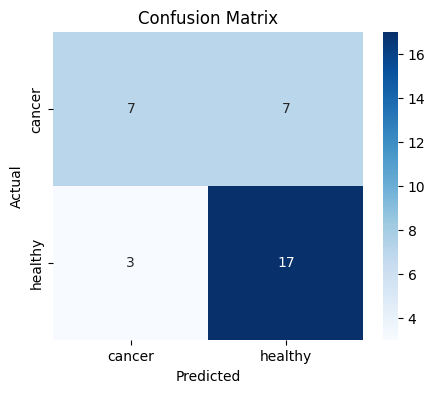

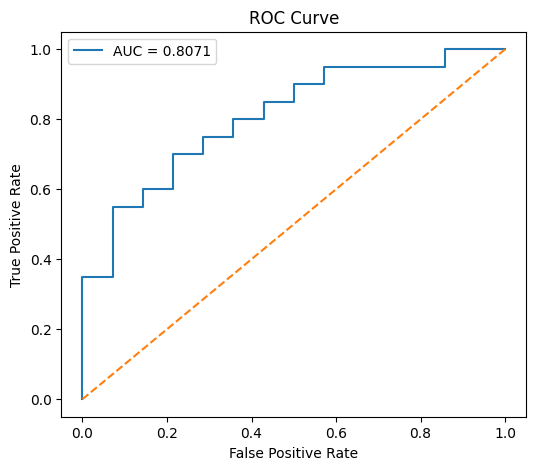

AUC Score: 0.8071428571428573


In [13]:
test_loss, test_acc = model19.evaluate(test_generator)
print("\nTest Accuracy:", test_acc)


#CONFUSION MATRIX

test_generator.reset()
pred_probs = model19.predict(test_generator)

pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_generator.classes

cm = confusion_matrix(true_labels, pred_labels)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
# Make sure target_names match the number of classes in true_labels and pred_labels
print(classification_report(true_labels, pred_labels, target_names=list(test_generator.class_indices.keys())))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
xticklabels=test_generator.class_indices.keys(),
yticklabels=test_generator.class_indices.keys(),
 cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC CURVE
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)



In [23]:
#Save model made for later uses
import numpy as np
import pandas as pd
from openpyxl import Workbook
model19.save("model19.h5")

#LOAD MODEL

model19 = load_model("model19.h5")


# EXTRACT DENSE(25) AND DENSE(2) LAYERS


# Identify Dense layers by units
dense_25_layer = None
dense_2_layer = None

for layer in model19.layers:
    if isinstance(layer, tf.keras.layers.Dense):
       if layer.units == 25:
            dense_25_layer = layer
       elif layer.units == 2:
            dense_2_layer = layer



# GET WEIGHTS AND BIASES

# Dense(25)
w25, b25 = dense_25_layer.get_weights()

# Dense(2)
w2, b2 = dense_2_layer.get_weights()

print("Dense(25) Weights Shape:", w25.shape)
print("Dense(25) Bias Shape:", b25.shape)

print("Dense(2) Weights Shape:", w2.shape)
print("Dense(2) Bias Shape:", b2.shape)

# SAVE TO EXCEL FILE


excel_file = "model19_classifier_weights.xlsx"

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:

# Dense(25)
    pd.DataFrame(w25).to_excel(writer, sheet_name="Dense25_Weights", index=False)
    pd.DataFrame(b25.reshape(1,-1)).to_excel(writer, sheet_name="Dense25_Bias", index=False)
# Dense(2)
    pd.DataFrame(w2).to_excel(writer, sheet_name="Dense2_Weights", index=False)
    pd.DataFrame(b2.reshape(1,-1)).to_excel(writer, sheet_name="Dense2_Bias", index=False)

print("Excel file saved as:", excel_file)


Dense(25) Weights Shape: (49, 25)
Dense(25) Bias Shape: (25,)
Dense(2) Weights Shape: (25, 2)
Dense(2) Bias Shape: (2,)
Excel file saved as: model19_classifier_weights.xlsx


#Weight pruning concept: Since so many weights are there, we can take an average and prune the range where we assume a certian value. This reduces number of parameters

Layer Name: dense
Units: 256
Weights Shape: (25088, 256)
Bias Shape: (256,)


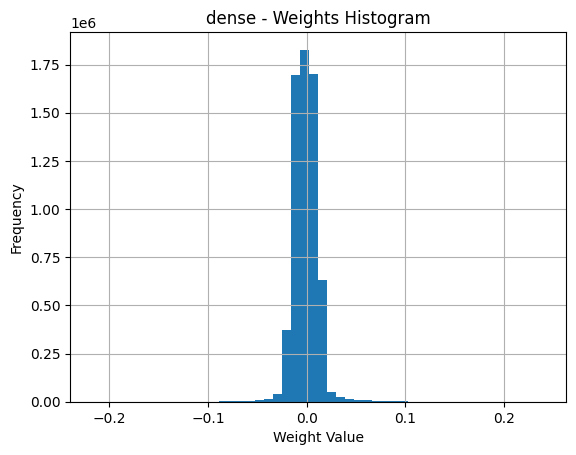

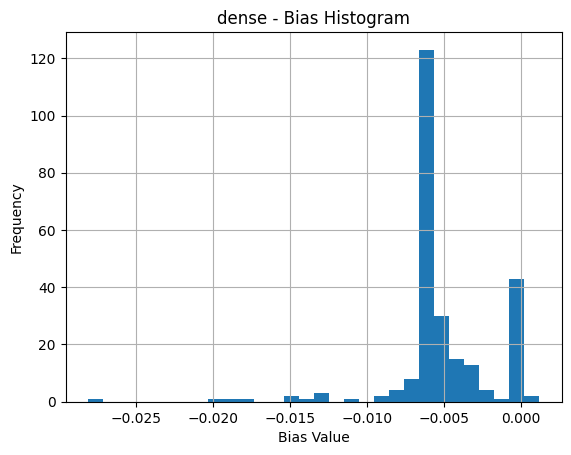

Layer Name: dense_1
Units: 2
Weights Shape: (256, 2)
Bias Shape: (2,)


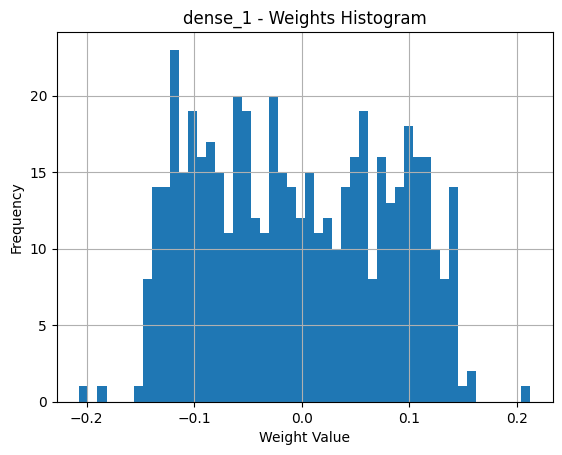

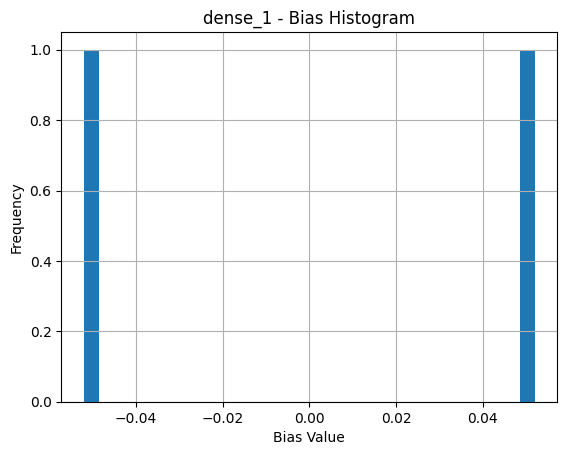

In [28]:
#Visualising result for pruning
dense_layers = [layer for layer in model.layers
                if isinstance(layer, tf.keras.layers.Dense)]

if len(dense_layers) < 2:
    print("Model has less than two Dense layers.")
else:
    # Select last two Dense layers
    layers_to_plot = dense_layers[-2:]


    # PLOT HISTOGRAMS

    for layer in layers_to_plot:

        weights, biases = layer.get_weights()

        weights_flat = weights.flatten()
        biases_flat = biases.flatten()


        print("Layer Name:", layer.name)
        print("Units:", layer.units)
        print("Weights Shape:", weights.shape)
        print("Bias Shape:", biases.shape)

        # Weight Histogram
        plt.figure()
        plt.hist(weights_flat, bins=50)
        plt.title(f"{layer.name} - Weights Histogram")
        plt.xlabel("Weight Value")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

        # Bias Histogram
        plt.figure()
        plt.hist(biases_flat, bins=30)
        plt.title(f"{layer.name} - Bias Histogram")
        plt.xlabel("Bias Value")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

#PRUNING THE DENSE WEIGHTS

In [31]:
import pandas as pd
import numpy as np


# LOAD EXCEL FILE

input_file = "model19_classifier_weights.xlsx"
sheet_name = "Dense25_Weights"

df = pd.read_excel(input_file, sheet_name=sheet_name)

print("Original Shape:", df.shape)

# Convert entire dataframe to numeric
df = df.apply(pd.to_numeric)

# COLUMN-WISE PRUNING (ALL ROWS)

for col in df.columns:

    column_data = df[col]

    # Masks
    negative_mask = column_data < -0.1
    positive_mask = column_data > 0.1
    small_mask = (column_data >= -0.1) & (column_data <= 0.1)

    # Compute means column-wise
    neg_mean = column_data[negative_mask].mean() if negative_mask.sum() > 0 else 0
    pos_mean = column_data[positive_mask].mean() if positive_mask.sum() > 0 else 0

    # Apply pruning
    df.loc[small_mask, col] = 0
    df.loc[negative_mask, col] = neg_mean
    df.loc[positive_mask, col] = pos_mean

# SAVE PRUNED FILE
output_file = "Dense25_Weights_pruned.xlsx"
df.to_excel(output_file, index=False)

print("Pruned file saved as:", output_file)

Original Shape: (49, 25)
Pruned file saved as: Dense25_Weights_pruned.xlsx


Observation: In the excel sheet we observe 3 values,negative mean(for values less than 1), 0(for values between -1 to 1) and positive mean (for values more than 1) based on histogram obtained. We can neglect 0 and hence number of parameters heavily reduces.

#WEIGHT SHARING
After doing pruning, we can check if weights are repeating in our new dataset



In [33]:
import pandas as pd

# LOAD PRUNED EXCEL FILE

input_file = "/content/Dense25_Weights_pruned.xlsx"
sheet_name = 0  # first sheet (or give sheet name)

df = pd.read_excel(input_file, sheet_name=sheet_name)

print("Loaded shape:", df.shape)

# 3. FIND REPEATED VALUES COLUMN-WISE
duplicate_locations = {}

for col in df.columns:

    column_data = df[col]

    # Group by value
    grouped = column_data.groupby(column_data)

    col_duplicates = {}

    for value, indices in grouped.groups.items():

        if len(indices) > 1:  # only repeated values
            col_duplicates[value] = list(indices)

    if col_duplicates:
        duplicate_locations[col] = col_duplicates


# PRINT RESULTS

for col, values in duplicate_locations.items():
    print("\n===================================")
    print("Column:", col)

    for value, rows in values.items():
        print(f"Value {value} found at rows: {rows}")

Loaded shape: (49, 25)

Column: 0
Value -0.1924514091677136 found at rows: [0, 9, 10, 12, 14, 16, 17, 19, 21, 24, 29, 31, 32, 35, 36, 40, 42, 43]
Value 0.0 found at rows: [3, 4, 6, 8, 13, 18, 20, 22, 23, 33, 34, 37, 38, 39, 41, 44, 46, 47, 48]
Value 0.1767933685332537 found at rows: [1, 2, 5, 7, 11, 15, 25, 26, 27, 28, 30, 45]

Column: 1
Value -0.1845886487175118 found at rows: [0, 2, 3, 4, 5, 6, 8, 10, 14, 15, 16, 17, 22, 23, 29, 30, 34, 36, 38, 40, 42, 44]
Value 0.0 found at rows: [9, 11, 19, 20, 21, 24, 25, 31, 32, 39]
Value 0.2019759600653368 found at rows: [1, 7, 12, 13, 18, 26, 27, 28, 33, 35, 37, 41, 43, 45, 46, 47, 48]

Column: 2
Value -0.2001050760348638 found at rows: [1, 7, 10, 11, 12, 17, 22, 23, 24, 28, 30, 31, 32, 33, 41, 42, 43, 45]
Value 0.0 found at rows: [2, 5, 6, 9, 15, 16, 19, 21, 25, 26, 27, 38, 39, 40, 47, 48]
Value 0.2021471609671911 found at rows: [0, 3, 4, 8, 13, 14, 18, 20, 29, 34, 35, 36, 37, 44, 46]

Column: 3
Value -0.1941448403965859 found at rows: [1, 3, 

Observation: In neural networks, if many weights have same values we can store that value once and share it across multiple connections; this reduces memory usage.

#CONVERSION TO FIXED POINT REPRESENTATION

In [38]:
import pandas as pd
import math

input_file = "Dense25_Weights_pruned.xlsx"
sheet_name = 0

df = pd.read_excel(input_file, sheet_name=sheet_name)

print("Loaded shape:", df.shape)


# FIXED FORMAT PARAMETERS

INTEGER_BITS = 2
FRACTIONAL_BITS = 5
MAX_INTEGER = 2**INTEGER_BITS - 1  # 3
MIN_INTEGER = - (2**INTEGER_BITS) # -4

#MANUAL Q2.5 CONVERSION
def float_to_manual_q2_5(value):

    # SIGN BIT
    if value < 0:
        sign_bit = '1'
    else:
        sign_bit = '0'

    abs_value = abs(value)

    # INTEGER PART
    integer_part = int(abs_value)

    #Clip integer overflow
    if integer_part > MAX_INTEGER:
        integer_part = MAX_INTEGER

    integer_binary = format(integer_part, '02b')

    #FRACTIONAL PART
    fractional_part = abs_value - integer_part
    fractional_bits = ""

    for _ in range(FRACTIONAL_BITS):
        fractional_part *= 2
        bit = int(fractional_part)
        fractional_bits += str(bit)
        fractional_part -= bit

    #COMBINE
    binary = sign_bit + integer_binary + fractional_bits

    return binary


#APPLY COLUMN-WISE
df_binary = df.copy()

for col in df_binary.columns:
    df_binary[col] = df_binary[col].apply(float_to_manual_q2_5)

output_file = "Dense25_Weights_Q2_5_manual_binary.xlsx"
df_binary.to_excel(output_file, index=False)

print("Manual Q2.5 binary file saved as:", output_file)

Loaded shape: (49, 25)
Manual Q2.5 binary file saved as: Dense25_Weights_Q2_5_manual_binary.xlsx


Note: Our aim is to make our model deployable on FPGA scale and resources. Hence to reduce mathematical operation(multiplication) during backpropagation at a level FPGA can handle, we convert to fixed point representation; it makes it easier to dump the model weights and parameters into FPGA and reduce computational cost as now multiplication is substituted with right/left shift operations.

After simulating on FPGA, we can possibly design an IC which can help in self-diagnosis of skin cancer; just like we have oximeter.

In FPGA we have BRAM for storing images and data, but first we need images in using our floating point representation in a  .coe file format

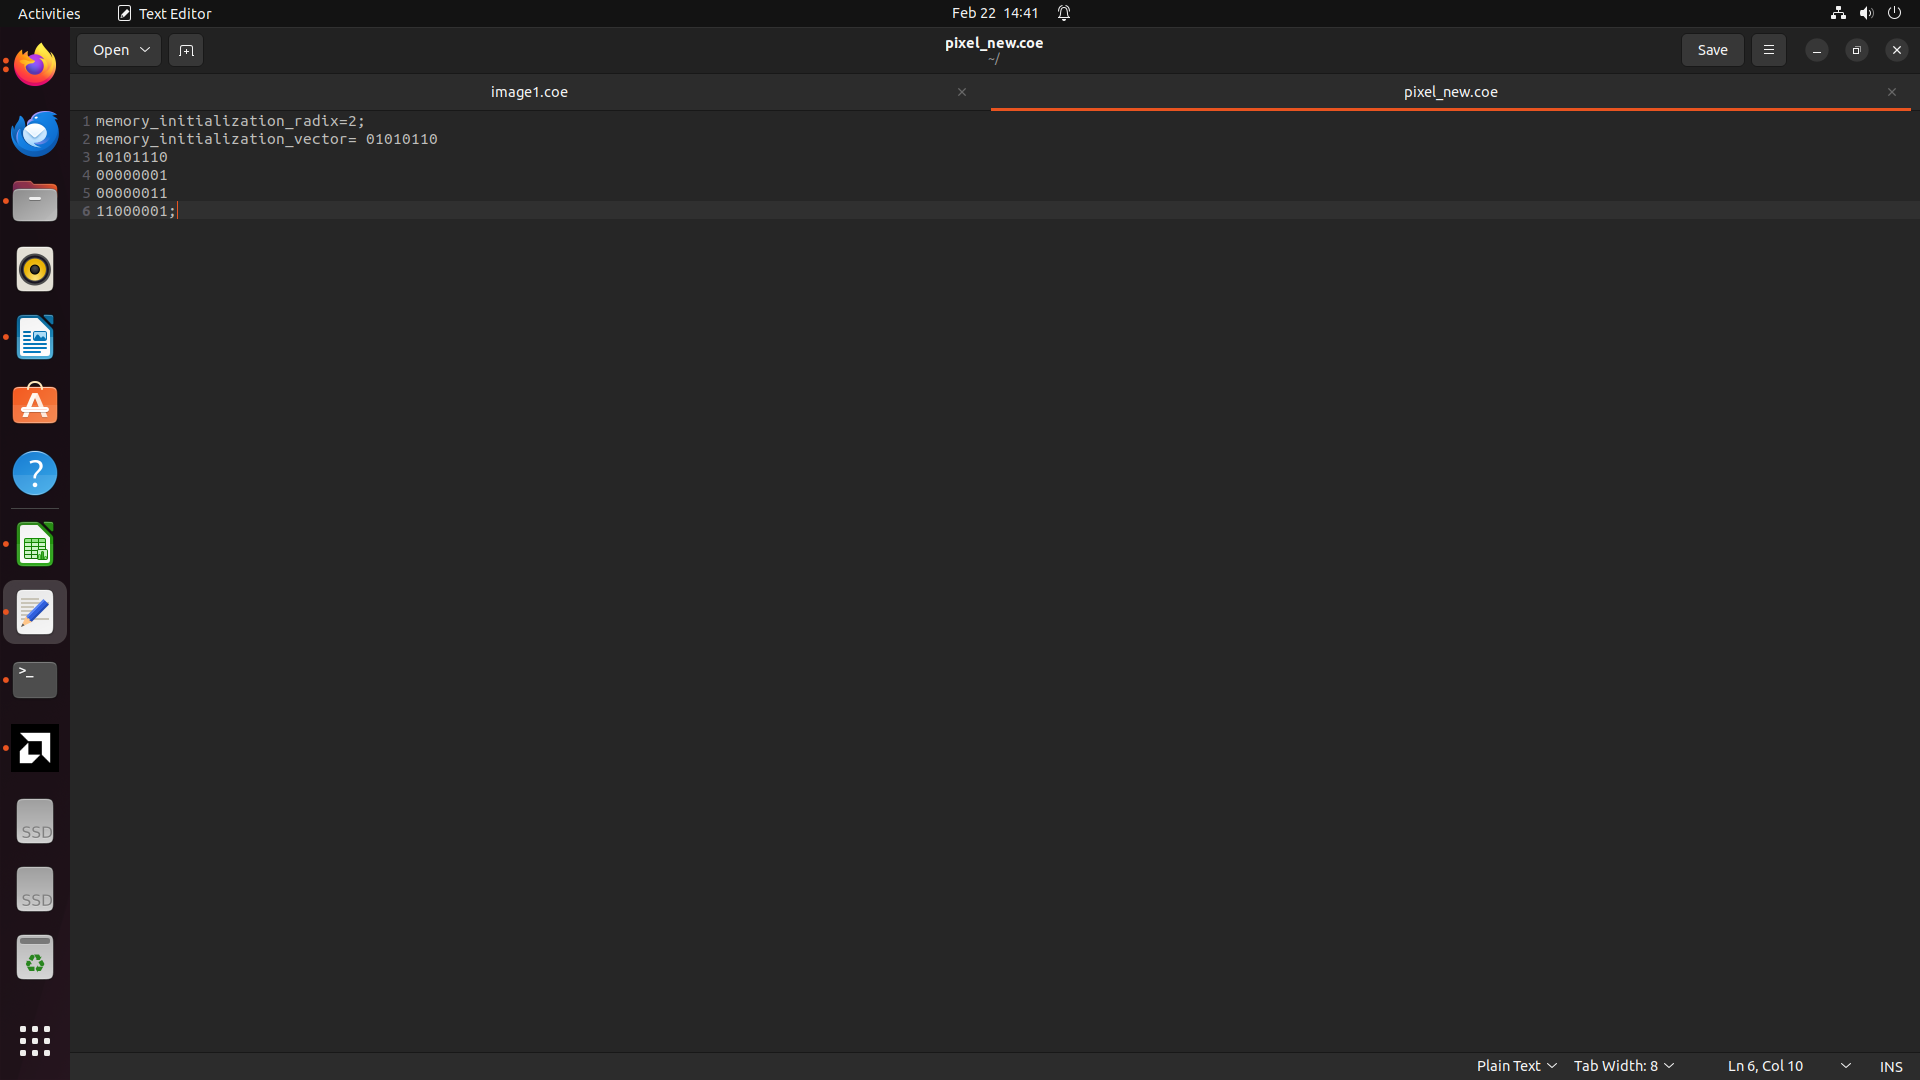

Port specifications on vivado

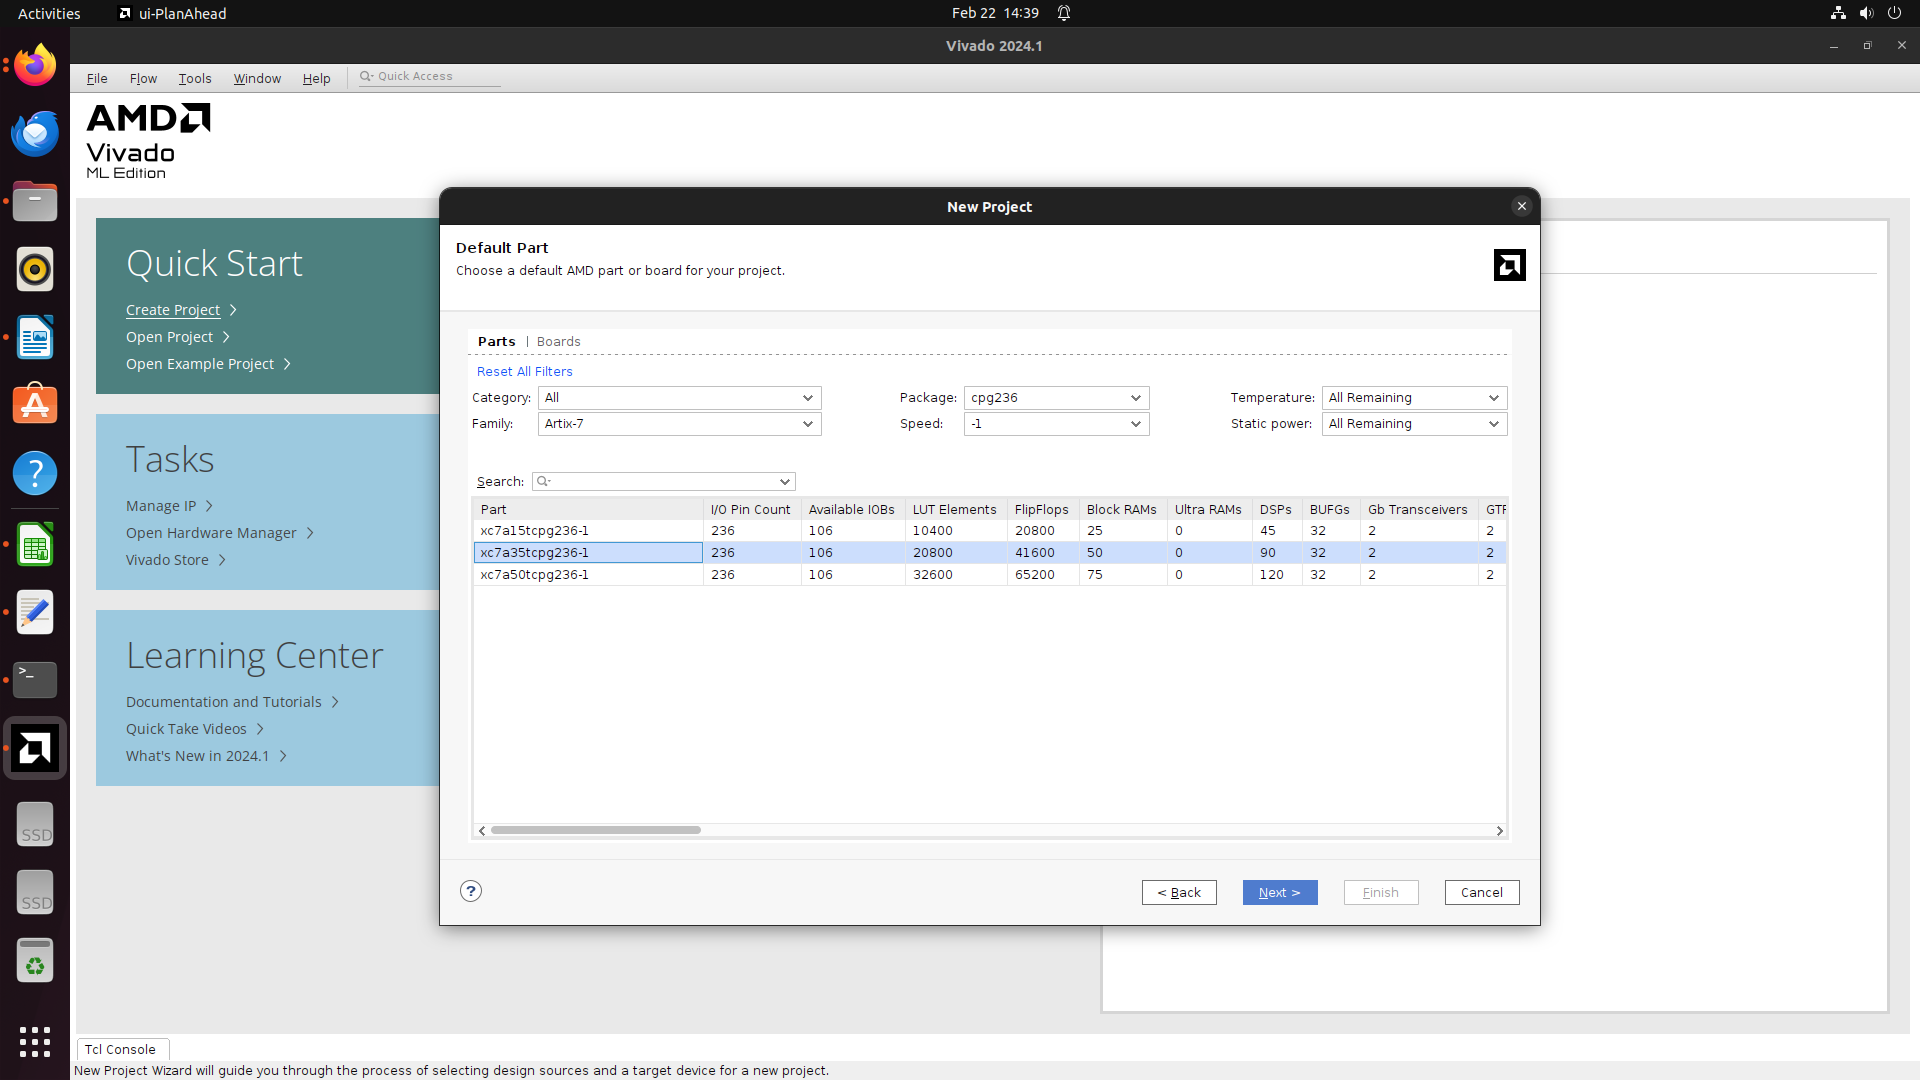

Our coe file has images of 784 pixels( as in .coe file 784 lines of 8 bit each) multiplied by 8 bits this product should be less tha 36 Kb as load in BRAM can only hold 36Kb.

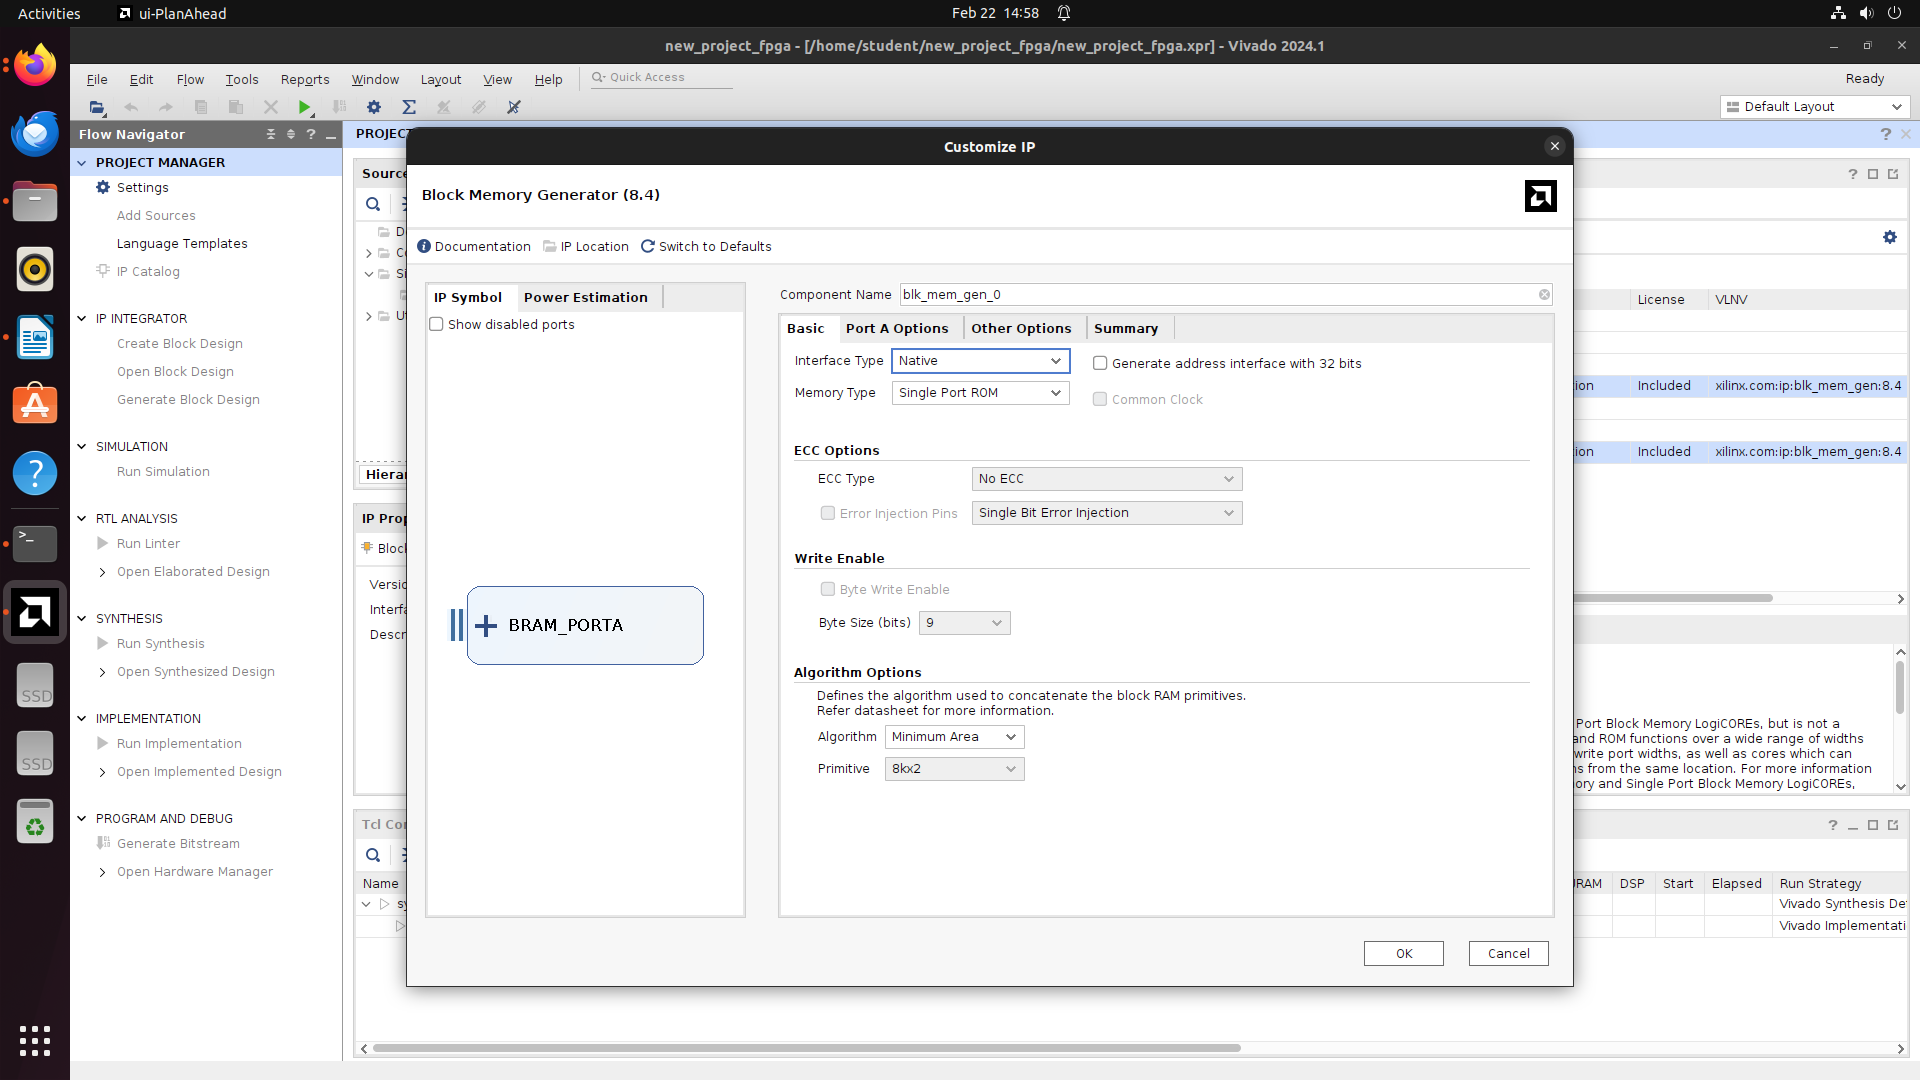

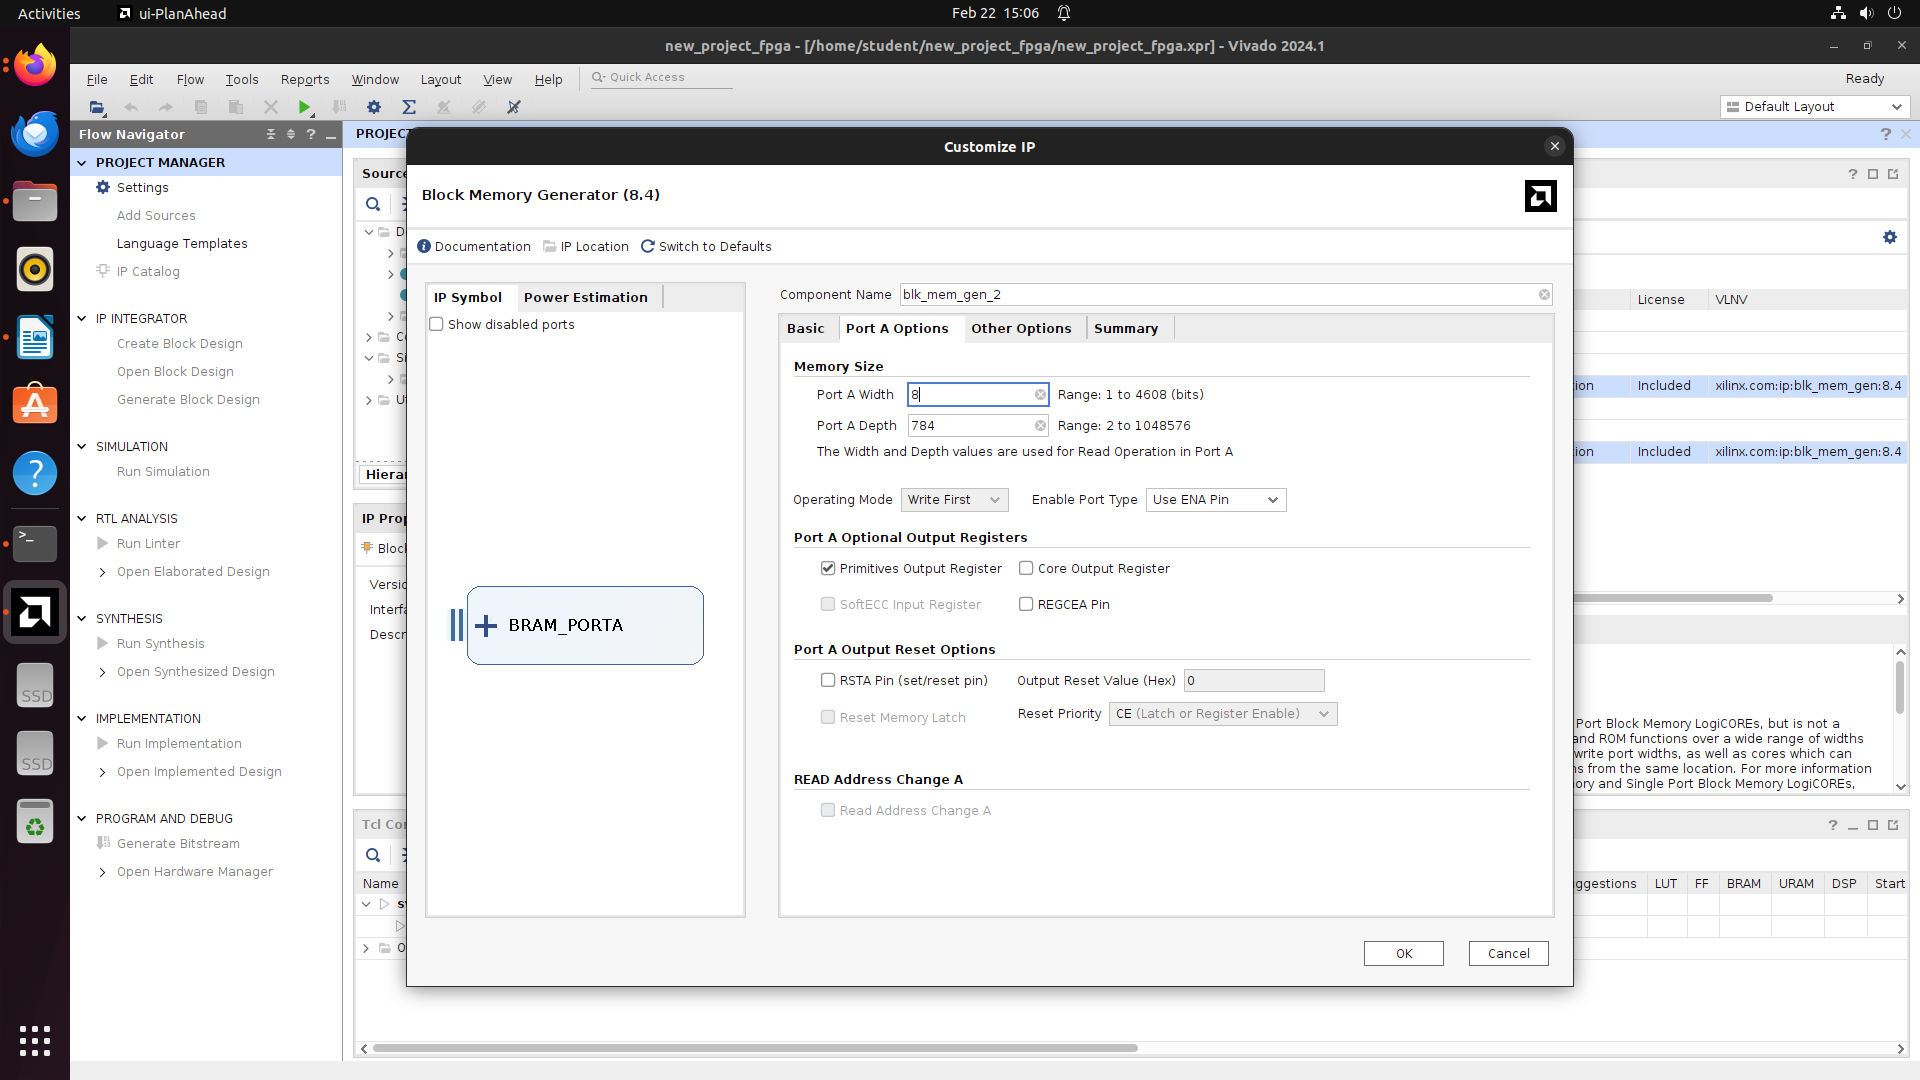

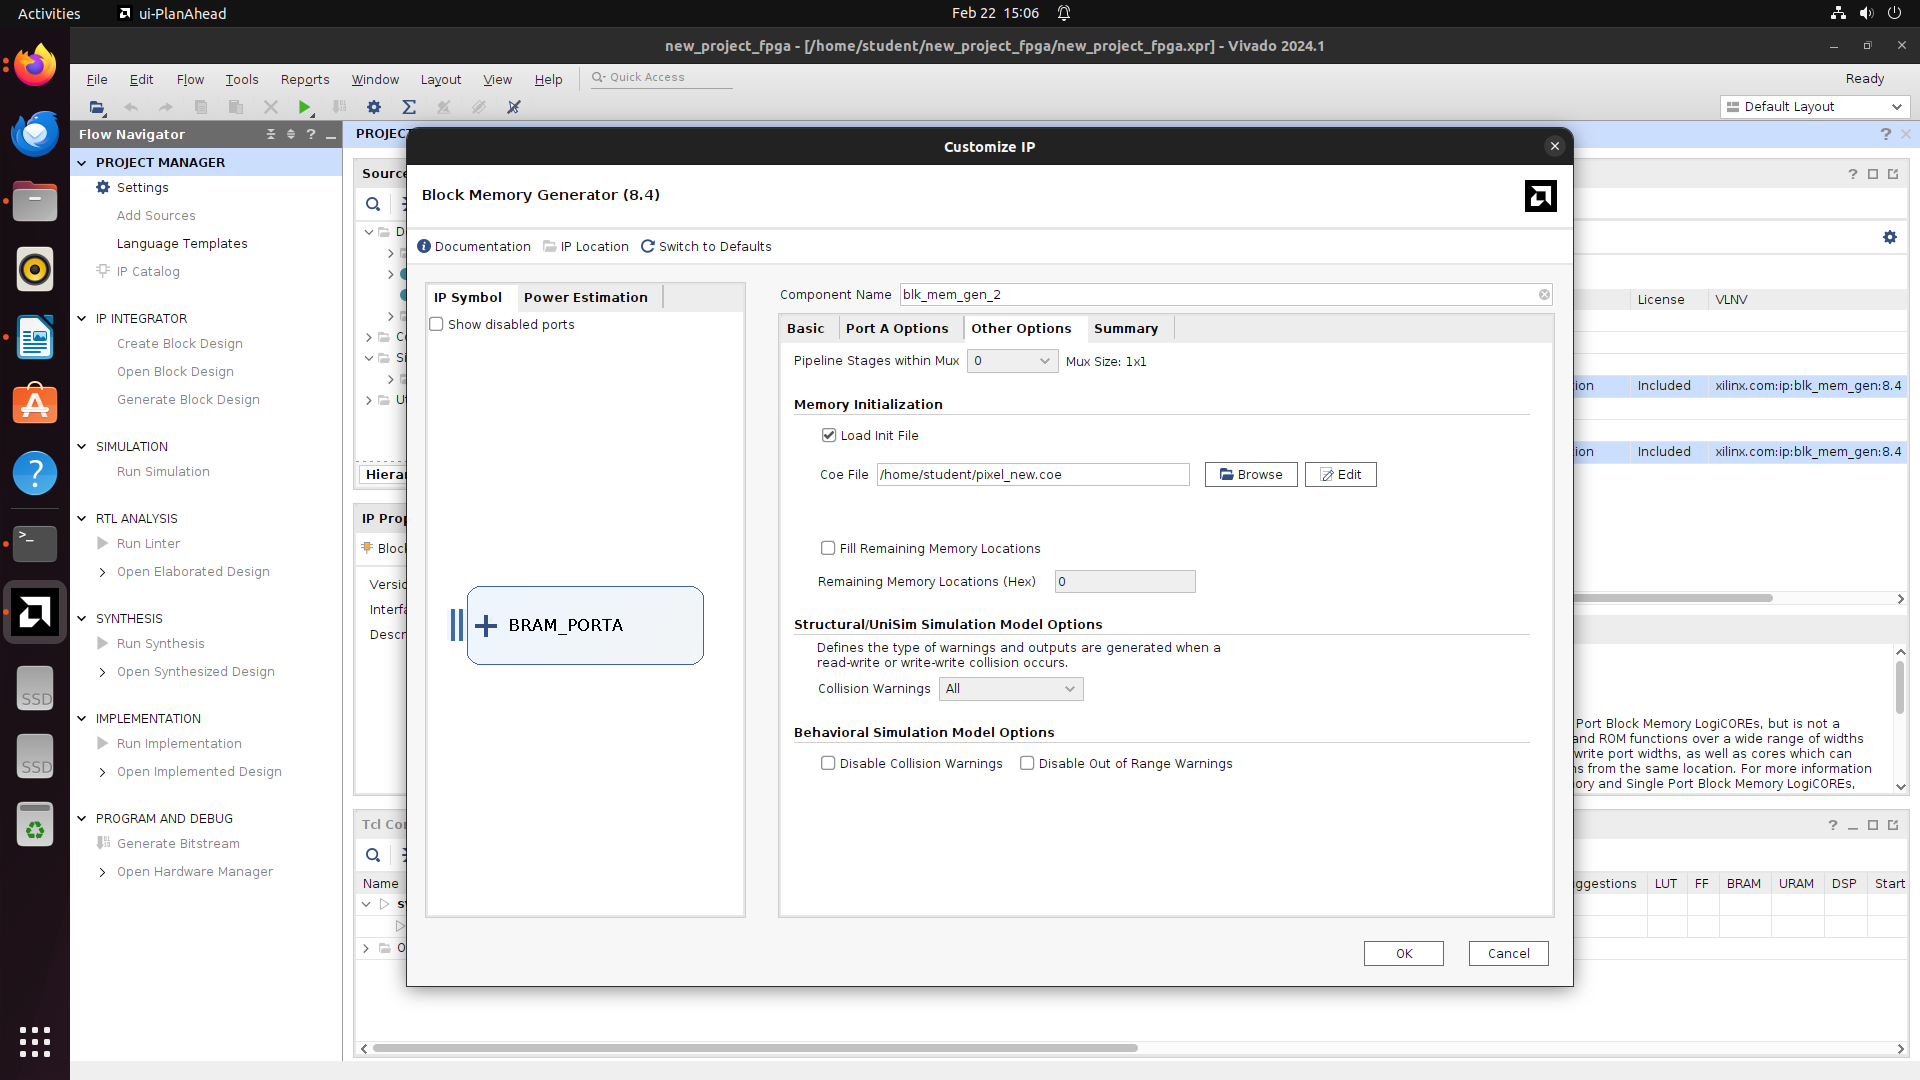

#verilog code for image reading on vivado in BRAM port

```
module counter (clk,en,out,i);
input clk,en; //clock reads data line by line of coe file
output reg[9:0] out=0; //784 pixels need variables and 2^9<784
//hence variable
//goes down from 9 to 0 hence occupying all pixels.
output reg[9:0]i=0;
always @(posedge clk)
begin
if (en)
begin
out<=out+1;
i<=i+1;
end
else
out<=out;
end
endmodule
//we need 1 extra clock time for variable to fetch data from BRAM and come
//back.
//main module
module imageread1(clk, en);
input clk, en;
//output reg [15:0] result [0:783];
reg [7:0] image1 [0:783];
reg [7:0] image2 [0:783];
wire [9:0] addr_a;
wire [9:0] out1;
wire [9:0] i;
reg [9:0] k;
wire [7:0] dout_a, dout_a1;

counter c1 (.clk(clk), .en(en), .out(out1), .i(i));
blk_mem_gen_0 your_instance_name (
  .clka(clk),    // input wire clka
  .ena(en),      // input wire ena
  .addra(addr_a),  // input wire [10 : 0] addra
  .douta(dout_a)  // output wire [10 : 0] douta
);
blk_mem_gen_1 your_instance_name1 (
  .clka(clk),    // input wire clka
  .ena(en),      // input wire ena
  .addra(addr_a),  // input wire [10 : 0] addra
  .douta(dout_a1)  // output wire [10 : 0] douta
);
assign addr_a=out1;
always @(posedge clk)
begin
k = i - 2'b10;
 if (k >= 10'd0 && k < 10'd784)
begin
image1[k] = dout_a;
image2[k] = dout_a1;
$display("image1 [%0d]=%0d, image2 [%0d]=%0d", k, image1 [k],k, image2 [k]);
//result[k] = image1[k] * image2[k];
//$display("result[%0d]=%0d",k,result[k]);
end
end
 endmodule
//testbench
module tb();
reg clk=0;
reg en;
wire [15:0]result[0:783];
imageread1 a1 (clk, en);
always #5 clk=~clk;
initial
begin
en=0;
#10 en=1;
#7900 en=0;
#10 $stop;
end
endmodule
);

```




#Output screenshots

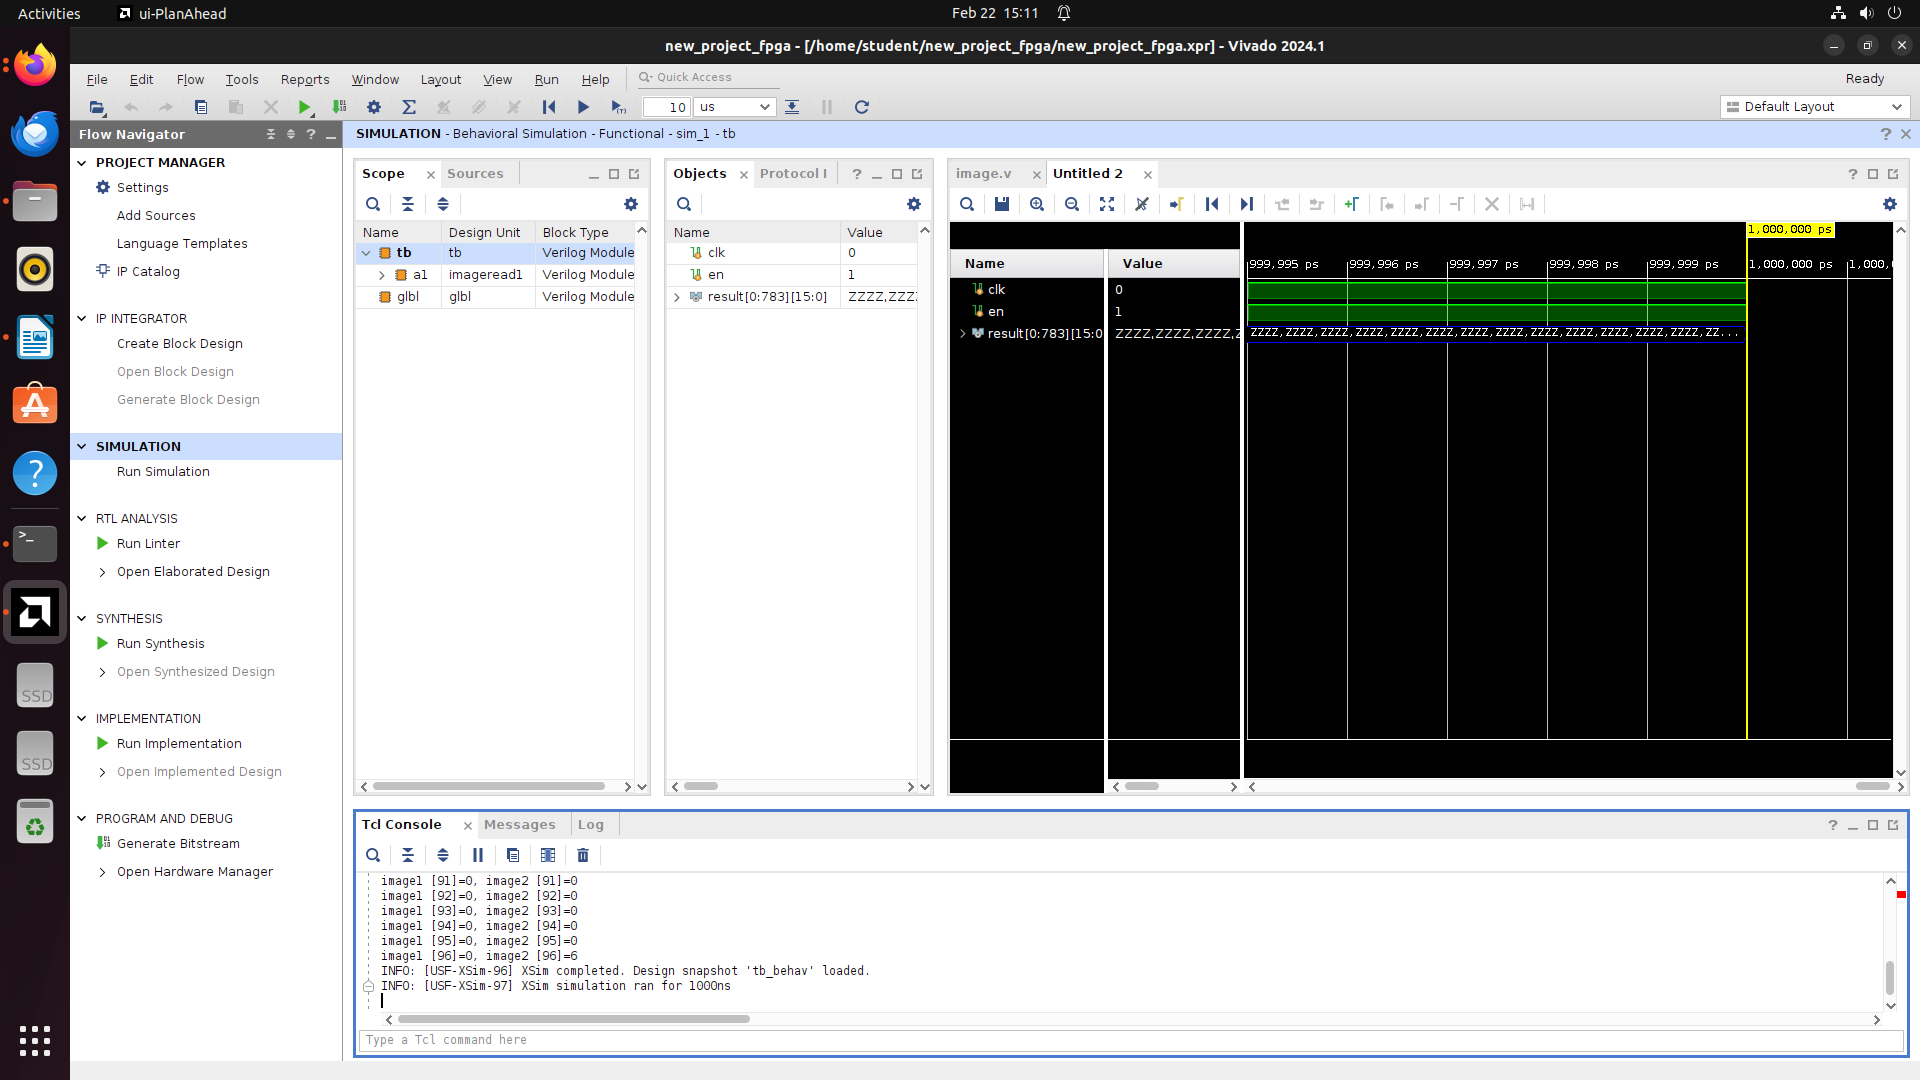

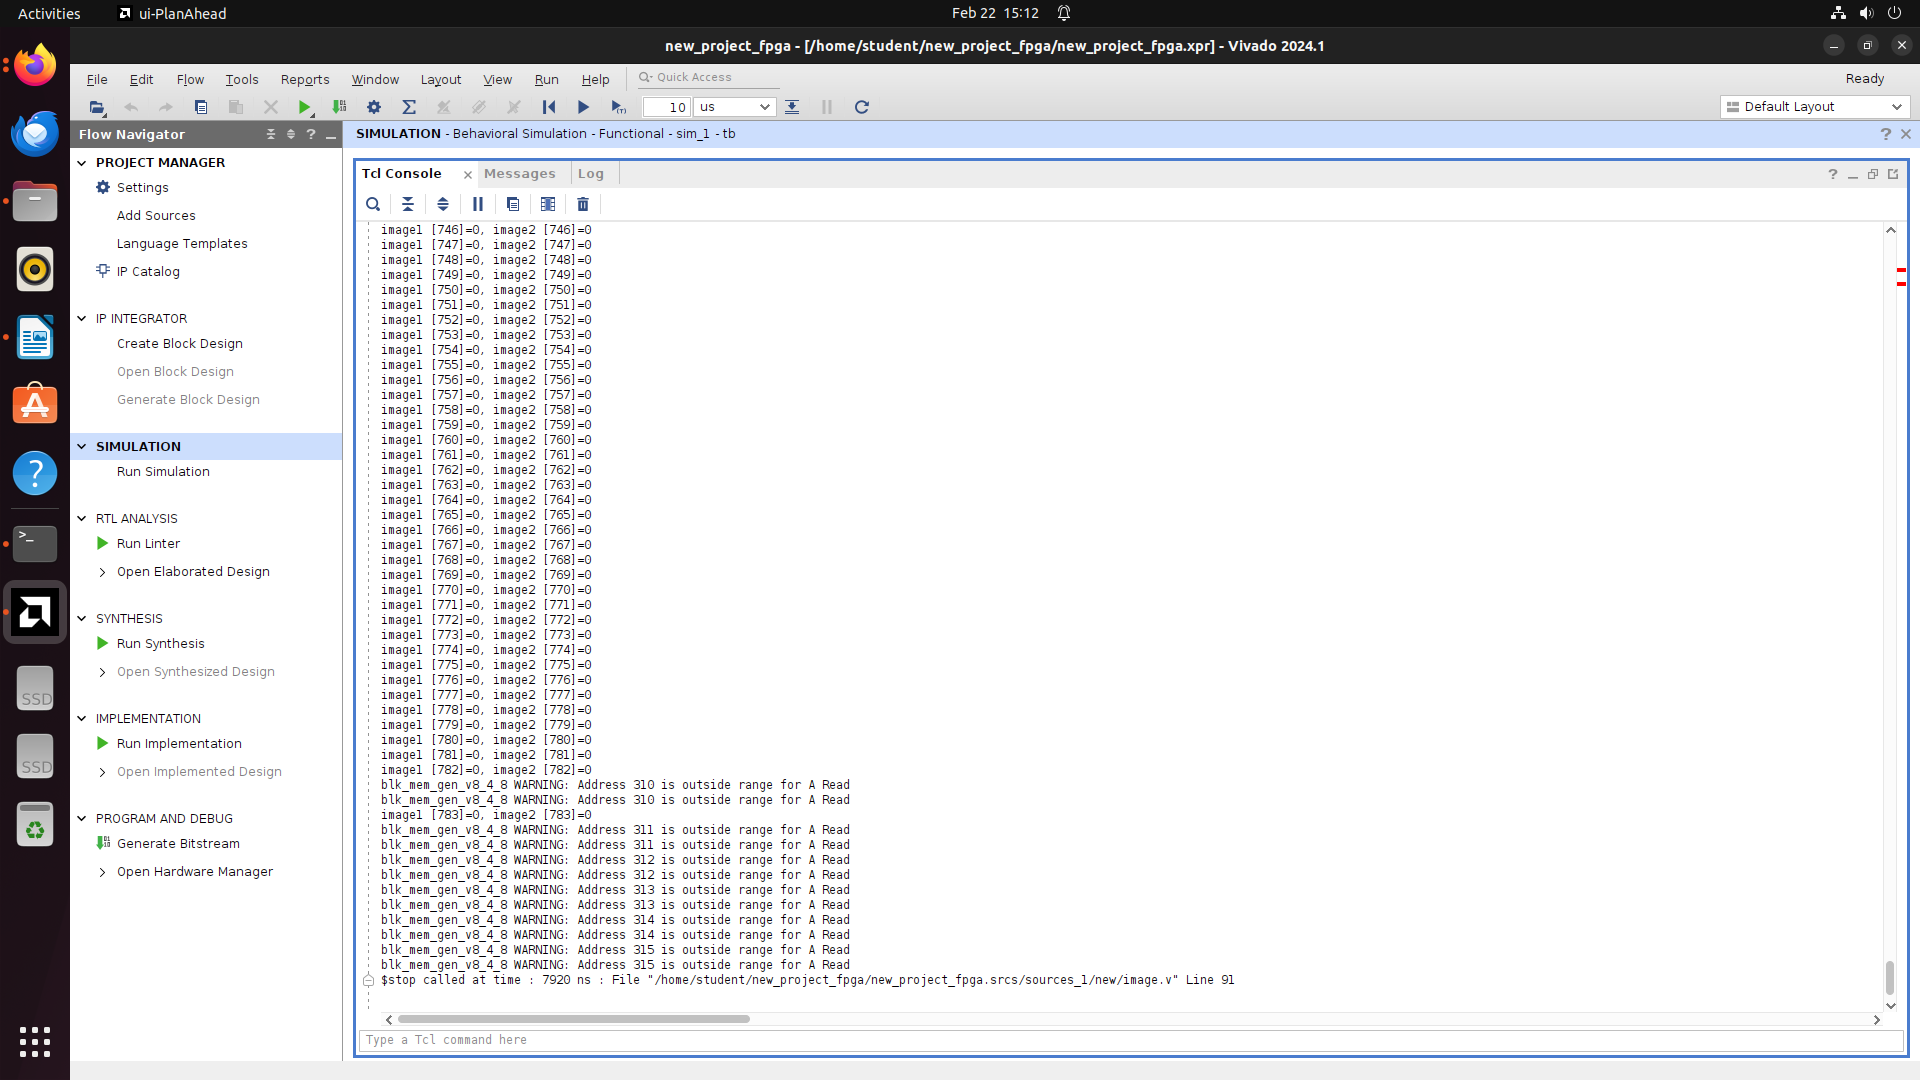